# Introduction to Computational Physics- Exercise Sheet 1

In [58]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
import sympy as sym
import math
import time

## Exercise 1

1.)  Inspect the function by plotting even and odd components for bound states.
Note characteristic features of the functions and discuss them. Make sure the
plot does not contain misleading lines!

In [23]:
def even(z,z0):
    return z*np.tan(z)-np.sqrt(z0**2-z**2)

def odd(z,z0):
    return np.where(np.tan(z) != 0, -z/np.tan(z)-np.sqrt(z0**2-z**2), -np.inf-np.sqrt(z0**2-z**2))

C:\Users\maaax\AppData\Local\Temp\ipykernel_21924\1820069745.py:5: RuntimeWarning: invalid value encountered in divide
  return np.where(np.tan(z) != 0, -z/np.tan(z)-np.sqrt(z0**2-z**2), -np.inf-np.sqrt(z0**2-z**2))


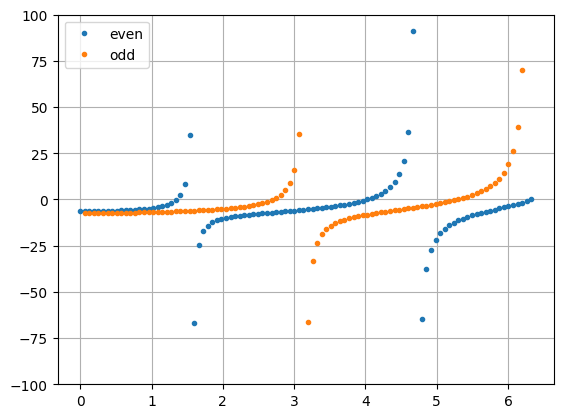

In [32]:
V0=20
z0=np.sqrt(2*V0)
z=np.linspace(0,z0,100)

plt.plot(z,even(z,z0),".",label="even")
plt.plot(z,odd(z,z0),".",label="odd")

plt.ylim(-100,100)
plt.legend()
plt.grid()
plt.show()

Both even and odd functions have roots and poles. Both of them have to roots in the interval (, last point is for z=z0 so outside open interval). Between the poles both functions are monotonously increasing and there is a sign change for both poles and roots. The sign change is from negative to positve for the roots!

2.) Write information output about the problem setup. For a given V0 your code
should tell the user how many roots (approximately) will be expected. Also,
your code should esimate whether the roots are likely to be of multiplicity 1
(simple root).

Use information that sign changes from negative to positive for roots

## <span style="color:red">Noch nicht fertig!!</span>

In [ ]:
def info(func,V0):
    z=np.linspace(0,V0)
    #roots via positive sign change:
    arr1=func(z[:-1],V0)*func(z[1:],V0)
    arr2=func(z[1:],V0)-func(z[:-1],V0)
    count = sum(1 for i in range(len(z)-1) if arr1[i] <= 0 and arr2[i]>0)
    
    
    return f"{count} roots "  

## Exercise 2 :root finding

In [177]:
def bisection(func,params,a,b,stop):
    """
    function tries to find roots via bisection method
    
    func: function
    params: parameter
    a: lower boundry of initial interval
    b: upper boundry of initial interval
    stop: stopping criteria of size of interval
    """
    while b-a>stop:
        p=(a+b)/2
        print(p)
        if func(p,*params)==0: 
            return f"root: {p}"
        if func(a,*params)*func(p,*params)<0:
            b=p
        else:
            a=p
    return p,a,b


def newton(func,func_prime,params,p0,stop):
    """
    function tries to find roots via Newton method
    
    func: function
    func_prime: derivative of function
    params: parameter
    p0: initial guess
    stop: stopping criteria for abs(f(pn))
    """
    p=p0
    while abs(func(p,*params))>stop:
        p=p-func(p,*params)/func_prime(p,*params)
        print(p)
    return p

def secant(func,params, p1, p2, stop):
    """
    function tries to find roots via secant method
    
    func: function
    params: parameter
    p1: first initial guess
    p2: second initial guess
    stop: stopping criteria for abs(f(pn))
    """
    while abs(func(p2,*params))>stop:
        p2,p1=p2-func(p2,*params)*(p2-p1)/(func(p2,*params)-func(p1,*params)),p2
        print(p2)
    return p2

In [179]:
V0=20
z0=np.sqrt(2*V0)

t=time.perf_counter()
value=bisection(even,np.array([z0]),3.8,4.2,10**-6)
print(f"value: {value[0]}, time: {time.perf_counter()-t}s, residual: {abs(even(value[0], z0))}")

4.0
4.1
4.05
4.025
4.0125
4.018750000000001
4.0218750000000005
4.0234375
4.022656250000001
4.023046875
4.0228515625000005
4.02294921875
4.022998046875
4.0229736328125
4.02296142578125
4.022967529296874
4.022970581054687
4.022972106933594
4.02297134399414
value: 4.02297134399414, time: 0.0010436000302433968s, residual: 3.972224440040861e-06


In [180]:
V0=20
z0=np.sqrt(2*V0)

def even_prime(z,z0):
    return np.tan(z)+z/np.cos(z)**2+z/np.sqrt(z0**2-z**2)

t=time.perf_counter()
value=newton(even, even_prime, np.array([z0]), 4, 10**-6)
print(f"value: {value}, time: {time.perf_counter()-t}s, residual: {abs(even(value, z0))}")

4.023613454138761
4.022972181239404
4.022971675556987
value: 4.022971675556987, time: 0.0010538999922573566s, residual: 3.76054742901033e-12


In [181]:
V0=20
z0=np.sqrt(2*V0)

t=time.perf_counter()
value=secant(even, np.array([z0]), 3.5, 4, 10**-6)
print(f"value: {value}, time: {time.perf_counter()-t}s, residual: {abs(even(value, z0))}")

4.036281966569151
4.022597060427044
4.022965539484705
4.022971678377912
value: 4.022971678377912, time: 0.0010958999628201127s, residual: 3.379934998548606e-08


## Comment:

number of iterations: bisection > secant > newton,  
runtime: bisection > secant > newton,   
residual: bisection > secant > newton

## Exercise 3

In [103]:
def secant(func,params, p1, p2, stop):
    """
    function tries to find roots via secant method
    
    func: function
    params: parameter
    p1: first initial guess
    p2: second initial guess
    stop: stopping criteria for abs(f(pn))
    """
    while abs(func(p2,*params))>stop:
        p2,p1=p2-func(p2,*params)*(p2-p1)/(func(p2,*params)-func(p1,*params)),p2
        #print(p2)
    return p2

In [151]:
V0=20
z0=np.sqrt(2*V0)

def allroots(func,params,stop):
    z=np.linspace(0,z0)[1:-1]
    arr1=func(z[:-1],*params)*func(z[1:],*params)
    arr2=func(z[1:],*params)-func(z[:-1],*params)
    
    #split at poles
    indices=[]
    for i in range(len(z)-1):
        if arr1[i] < 0 and arr2[i]<0:
            indices.append(i+1)

    z_neu=np.split(z,indices)
    
    #use secant method
    roots=[]
    for j in range(len(z_neu)):
        a,b=z_neu[j][-3],z_neu[j][-2]
        p=secant(func,params, a, b, stop)
        if p>0 and p<z0:
            roots.append(p)
    return np.array(roots)

In [152]:
rootseven=allroots(even,np.array([z0]),10**-6)
rootsodd=allroots(odd,np.array([z0]),10**-6)
rootseven,rootsodd

C:\Users\maaax\AppData\Local\Temp\ipykernel_21924\1820069745.py:2: RuntimeWarning: invalid value encountered in sqrt
  return z*np.tan(z)-np.sqrt(z0**2-z**2)


(array([1.35489515, 4.0229717 ]), array([2.70044473, 5.29191086]))

In [154]:
energy_even=rootseven**2/2-V0
energy_odd=rootsodd**2/2-V0
energy_even,energy_odd

(array([-19.08212956, -11.90784937]), array([-16.35379912,  -5.99783972]))

parity-seperated formulation is numerically useful, because like that we can define two functions f_even and f_odd, which roots define the value z for which wavefunction fulfill matching psi and psi'.

## Exercise 4

In [184]:
def bisection(func,params,a,b,stop):
    """
    function tries to find roots via bisection method
    
    func: function
    params: parameter
    a: lower boundry of initial interval
    b: upper boundry of initial interval
    stop: stopping criteria of size of interval
    """
    iterations=0
    while b-a>stop:
        p=(a+b)/2
        #print(p)
        if func(p,*params)==0: 
            return f"root: {p}"
        if func(a,*params)*func(p,*params)<0:
            b=p
        else:
            a=p
        iterations+=1
    return p,iterations


def newton(func,func_prime,params,p0,stop):
    """
    function tries to find roots via Newton method
    
    func: function
    func_prime: derivative of function
    params: parameter
    p0: initial guess
    stop: stopping criteria for abs(f(pn))
    """
    p=p0
    iterations=0
    
    while abs(func(p,*params))>stop:
        p=p-func(p,*params)/func_prime(p,*params)
        #print(p)
        iterations+=1
    return p, iterations

def secant(func,params, p1, p2, stop):
    """
    function tries to find roots via secant method
    
    func: function
    params: parameter
    p1: first initial guess
    p2: second initial guess
    stop: stopping criteria for abs(f(pn))
    """
    iterations=0
    
    while abs(func(p2,*params))>stop:
        p2,p1=p2-func(p2,*params)*(p2-p1)/(func(p2,*params)-func(p1,*params)),p2
        #print(p2)
        iterations+=1
    return p2, iterations

Pick root of even function at approx. 4

In [205]:
tolerances=np.array([10**-4, 10**-8, 10**-12])

#bisection method
table1=np.zeros((3,2))
p1=np.zeros(3)
for i in range(len(tolerances)):
    t=time.perf_counter()
    p1[i],table1[i][0]=bisection(even,np.array([z0]),3.0,5,tolerances[i])
    table1[i][1]=time.perf_counter()-t

#newton method
table2=np.zeros((3,2))
p2=np.zeros(3)
for i in range(len(tolerances)):
    t=time.perf_counter()
    p2[i],table2[i][0]=newton(even, even_prime, np.array([z0]), 4, tolerances[i])
    table2[i][1]=time.perf_counter()-t

table3=np.zeros((3,2))
p3=np.zeros(3)
for i in range(len(tolerances)):
    t=time.perf_counter()
    p3[i],table3[i][0]=secant(even, np.array([z0]), 3.5, 4, tolerances[i])
    table3[i][1]=time.perf_counter()-t

#table1, table2, table3
df1=pd.DataFrame(table1,columns=["Iterations", "time (s)"],index=["tol=1e-4", "tol=1e-8", "tol=1e-12"])
df2=pd.DataFrame(table2,columns=["Iterations", "time (s)"],index=["tol=1e-4", "tol=1e-8", "tol=1e-12"])
df3=pd.DataFrame(table3,columns=["Iterations", "time (s)"],index=["tol=1e-4", "tol=1e-8", "tol=1e-12"])

print("Bisection method")
print(df1)
print("\n Newton method")
print(df2)
print("\n Secant method")
print(df3)

Bisection method
           Iterations  time (s)
tol=1e-4         15.0  0.000390
tol=1e-8         28.0  0.000844
tol=1e-12        41.0  0.001051

 Newton method
           Iterations  time (s)
tol=1e-4          2.0  0.000115
tol=1e-8          3.0  0.000100
tol=1e-12         4.0  0.000118

 Secant method
           Iterations  time (s)
tol=1e-4          3.0  0.000149
tol=1e-8          5.0  0.000158
tol=1e-12         5.0  0.000161


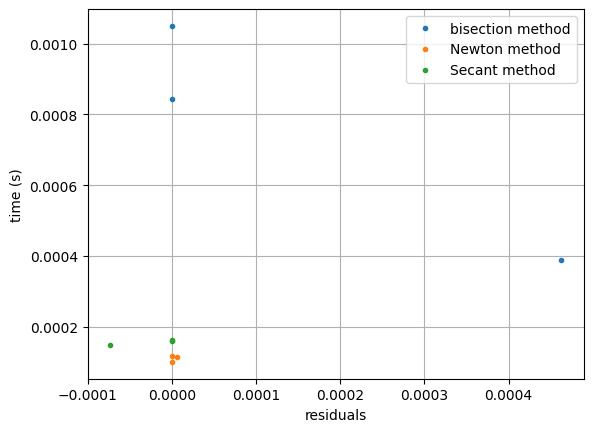

In [208]:
plt.plot(even(p1,z0),df1["time (s)"], ".", label="bisection method")
plt.plot(even(p2,z0),df2["time (s)"], ".", label="Newton method")
plt.plot(even(p3,z0),df3["time (s)"], ".", label="Secant method")

plt.xlabel("residuals")
plt.ylabel("time (s)")

plt.legend()
plt.grid()
plt.show()

### Discussion:
As we saw before: bisection method needs most iterations and also most time, followed by secant method, Newton method is the best!